In [1]:
from pathlib import Path
from time import perf_counter
import cProfile
import os
import pstats
import numpy as np
import sys

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "src").exists():
    ROOT_DIR = ROOT_DIR.parent
    
SRC_ROOT = ROOT_DIR / "src"
sys.path.insert(0, str(SRC_ROOT))

os.environ.setdefault("GRB_LICENSE_FILE", str(ROOT_DIR / "gurobi.lic"))

from PolyRound import main as pr_old   # Packaged
import hopsy._polyround as pr_new      # Vendored


In [2]:
from pathlib import Path
import json
import urllib.request

out_dir = ROOT_DIR / "examples" / "test_data"
out_dir.mkdir(parents=True, exist_ok=True)

# Get all BiGG model IDs
with urllib.request.urlopen("http://bigg.ucsd.edu/api/v2/models") as response: data = json.load(response)

model_ids = [m["bigg_id"] for m in data["results"]]

# Download each model as .xml.gz
for model_id in model_ids:
  url = f"http://bigg.ucsd.edu/static/models/{model_id}.xml.gz"
  target = out_dir / f"{model_id}.xml.gz"

  if target.exists():
    print(f"Skipping {model_id}; already exists at {target}")
    continue

  tmp_target = target.with_name(target.name + ".part")
  tmp_target.unlink(missing_ok=True)

  print(f"Downloading {model_id} > {target}")
  urllib.request.urlretrieve(url, tmp_target)

  tmp_target.replace(target)

Skipping e_coli_core; already exists at /home/edoar/Projects/fzj/hopsy-196/examples/test_data/e_coli_core.xml.gz
Skipping iAB_RBC_283; already exists at /home/edoar/Projects/fzj/hopsy-196/examples/test_data/iAB_RBC_283.xml.gz
Skipping iAF1260; already exists at /home/edoar/Projects/fzj/hopsy-196/examples/test_data/iAF1260.xml.gz
Skipping iAF1260b; already exists at /home/edoar/Projects/fzj/hopsy-196/examples/test_data/iAF1260b.xml.gz
Skipping iAF692; already exists at /home/edoar/Projects/fzj/hopsy-196/examples/test_data/iAF692.xml.gz
Skipping iAF987; already exists at /home/edoar/Projects/fzj/hopsy-196/examples/test_data/iAF987.xml.gz
Skipping iAM_Pb448; already exists at /home/edoar/Projects/fzj/hopsy-196/examples/test_data/iAM_Pb448.xml.gz
Skipping iAM_Pc455; already exists at /home/edoar/Projects/fzj/hopsy-196/examples/test_data/iAM_Pc455.xml.gz
Skipping iAM_Pf480; already exists at /home/edoar/Projects/fzj/hopsy-196/examples/test_data/iAM_Pf480.xml.gz
Skipping iAM_Pk459; already e

In [9]:
import gzip
import shutil
import cobra

MODELS_DIR = ROOT_DIR / "examples" / "test_data"

SELECTED_MODEL = [
    # Small BiGG models by .xml.gz archive size.
    "e_coli_core.xml.gz",
    "iAB_RBC_283.xml.gz",
    # "iIS312.xml.gz",
    # "iIS312_Epimastigote.xml.gz",
    # "iIS312_Amastigote.xml.gz",
    
    # Medium BiGG models by .xml.gz archive size.
    "iZ_1308.xml.gz",
    "iUMN146_1321.xml.gz",
    # "iNRG857_1313.xml.gz",
    # "iECSP_1301.xml.gz",
    # "RECON1.xml.gz",
    
    # Large BiGG models by .xml.gz archive size.
    "iCHOv1_DG44.xml.gz",
    "iML1515.xml.gz",
    # "iMM1415.xml.gz",
    # "iCHOv1.xml.gz",
    # "Recon3D.xml.gz",
]

MODELS = [MODELS_DIR / name for name in SELECTED_MODEL]

# N_MODELS = 10
# MODELS = sorted(
#     MODELS_DIR.glob("*.xml.gz"),
#     key=lambda p: p.stat().st_size,
# )[:N_MODELS]

print(f"Using these {len(MODELS)} models:")

for path in MODELS:
    print(f"  {path.name:<35} {path.stat().st_size / 1024:>10.1f} KiB")

SETTINGS = {
    "thresh": 1e-7,
    "verbose": False,
    "sgp": False,
    "reduce": True,
    "presolve": True,
    "regularize": False,
    "check_lps": False,
    "hp_flags": {
        "FeasibilityTol": 1e-9,
        "OptimalityTol": 1e-8,
        "Threads": 1,
        # "Method": -1,
    },
}

RUNS = [
    ("pr_old", 
     pr_old, 
     [
         "gurobi",
         #"glpk"
     ]),
    ("pr_new", 
     pr_new, 
     [
         "gurobi", 
         # "glpk",
         #"highs", 
         "gurobi-cupy"
     ])
]


Using these 6 models:
  e_coli_core.xml.gz                        34.7 KiB
  iAB_RBC_283.xml.gz                       120.3 KiB
  iZ_1308.xml.gz                           499.0 KiB
  iUMN146_1321.xml.gz                      499.7 KiB
  iCHOv1_DG44.xml.gz                       599.6 KiB
  iML1515.xml.gz                           605.6 KiB


In [ ]:
def make_settings(pr_module, backend):
    return pr_module.PolyRoundSettings(
        backend=backend,
        hp_flags=dict(SETTINGS["hp_flags"]),
        thresh=SETTINGS["thresh"],
        verbose=SETTINGS["verbose"],
        sgp=SETTINGS["sgp"],
        reduce=SETTINGS["reduce"],
        regularize=SETTINGS["regularize"],
        check_lps=SETTINGS["check_lps"],
        presolve=SETTINGS["presolve"],
    )


def sbml_to_polytope(pr_module, model_path, settings):
    if hasattr(pr_module, "StoichiometryParser"):
        return pr_module.StoichiometryParser.parse_sbml_cobrapy(
            str(model_path),
        )

    return pr_module.PolyRoundApi.sbml_to_polytope(
        str(model_path),
        settings=settings,
    )

def polytope_snapshot(polytope):
    S = getattr(polytope, "S", None)
    h = getattr(polytope, "h", None)
    transformation = getattr(polytope, "transformation", None)
    shift = getattr(polytope, "shift", None)
    return {
        "A": np.asarray(polytope.A.values).copy(),
        "b": np.asarray(polytope.b.values).copy(),
        "S": np.asarray([] if S is None else S.values).copy(),
        "h": np.asarray([] if h is None else h.values).copy(),
        "transformation": np.asarray(
            np.eye(polytope.A.shape[1]) if transformation is None else transformation.values
        ).copy(),
        "shift": np.asarray(
            np.zeros(polytope.A.shape[1]) if shift is None else shift.values
        ).copy(),
    }


def append_timing(model_name, pr_name, backend, stage, seconds):
    timings.append(
        {
            "model": model_name,
            "pr": pr_name,
            "backend": backend,
            "stage": stage,
            "seconds": seconds,
        }
    )


RESULTS = {}
timings = []

if "profiler" in globals():
    profiler.disable()

print()
print(" --- Settings --- ")
print()
for key, value in SETTINGS.items():
    print(f"{key:<16}{value}")

print()
print(" --- Run --- ")
print()
print(f"Selected {len(MODELS)} models from {MODELS_DIR}")

for gz_path in MODELS:
    model_path = gz_path.with_suffix("")  # .xml.gz -> .xml
    model_name = model_path.name

    try:
        print()
        print(f"Extracting {gz_path.name} > {model_name}", flush=True)
        print(f"Running {model_name}", flush=True)
        with gzip.open(gz_path, "rb") as src:
            with open(model_path, "wb") as dst:
                shutil.copyfileobj(src, dst)

        for pr_name, pr, backends in RUNS:
            for backend in backends:
                try:
                    print()
                    print(f"{model_name} - {pr_name} - {backend}", flush=True)

                    settings = make_settings(pr, backend)
                    profiler = cProfile.Profile()
                    backend_total = 0.0

                    # Parse
                    start = perf_counter()
                    parsed = sbml_to_polytope(
                        pr,
                        model_path,
                        settings=settings,
                    )
                    stop = perf_counter()
                    parse_elapsed = stop - start
                    backend_total += parse_elapsed
                    print(f"{'':<8}", f"{'parse':<30}{parse_elapsed:>10.3f}s", flush=True)
                    append_timing(model_name, pr_name, backend, "parse", parse_elapsed)
                    RESULTS[(model_name, pr_name, backend, "parse")] = polytope_snapshot(parsed)

                    # Simplify
                    start = perf_counter()
                    profiler.enable()
                    try:
                        simplified = pr.PolyRoundApi.simplify_polytope(parsed, settings=settings)
                    finally:
                        profiler.disable()
                    stop = perf_counter()
                    simplify_elapsed = stop - start
                    backend_total += simplify_elapsed
                    print(f"{'':<8}", f"{'simplify':<30}{simplify_elapsed:>10.3f}s", flush=True)
                    append_timing(model_name, pr_name, backend, "simplify", simplify_elapsed)
                    RESULTS[(model_name, pr_name, backend, "simplify")] = polytope_snapshot(simplified)

                    # Transform
                    start = perf_counter()
                    profiler.enable()
                    try:
                        round_input = simplified
                        if not simplified.inequality_only:
                            round_input = pr.PolyRoundApi.transform_polytope(simplified, settings=settings)
                    finally:
                        profiler.disable()
                    stop = perf_counter()
                    transform_elapsed = stop - start
                    backend_total += transform_elapsed
                    print(f"{'':<8}", f"{'transform':<30}{transform_elapsed:>10.3f}s", flush=True)
                    append_timing(model_name, pr_name, backend, "transform", transform_elapsed)
                    RESULTS[(model_name, pr_name, backend, "transform")] = polytope_snapshot(round_input)

                    # Round
                    start = perf_counter()
                    profiler.enable()
                    try:
                        rounded = pr.PolyRoundApi.round_polytope(round_input, settings=settings)
                    finally:
                        profiler.disable()
                    stop = perf_counter()
                    round_elapsed = stop - start
                    backend_total += round_elapsed
                    print(f"{'':<8}", f"{'round':<30}{round_elapsed:>10.3f}s", flush=True)
                    append_timing(model_name, pr_name, backend, "round", round_elapsed)
                    print(f"{'':<8}", f"{'total':<30}{backend_total:>10.3f}s", flush=True)
                    append_timing(model_name, pr_name, backend, "total", backend_total)
                    RESULTS[(model_name, pr_name, backend, "round")] = polytope_snapshot(rounded)

                    print()
                    print(" --- Profiling --- ")
                    print()
                    stats = pstats.Stats(profiler).strip_dirs()
                    stats.sort_stats("tottime").print_stats(5)
                    stats.sort_stats("cumtime").print_stats(5)
                    stats.print_callers(5)
                    stats.print_callees(5)

                except Exception as exc:
                    print(
                        f"FAILED: {model_name} - {pr_name} - {backend}: {type(exc).__name__}: {exc}",
                        flush=True,
                    )

    except Exception as exc:
        print(
            f"FAILED: {model_name}: {type(exc).__name__}: {exc}",
            flush=True,
        )

    finally:
        model_path.unlink(missing_ok=True)

print()
print(" --- Timings --- ", flush=True)
print()
print(f"{'model':<30}{'pr':<10}{'backend':<12}{'stage':<12}{'time':>10}")
print()

previous = None
for timing in timings:
    current = (timing["model"], timing["pr"], timing["backend"])
    if previous is not None and current != previous:
        print()
    previous = current
    seconds = f"{timing['seconds']:.3f}s"
    print(
        f"{timing['model']:<30}"
        f"{timing['pr']:<10}"
        f"{timing['backend']:<12}"
        f"{timing['stage']:<12}"
        f"{seconds:>10}"
    )



 --- Settings --- 

thresh          1e-07
verbose         False
sgp             False
reduce          True
presolve        True
regularize      False
check_lps       False
hp_flags        {'FeasibilityTol': 1e-09, 'OptimalityTol': 1e-08, 'Threads': 1}

 --- Run --- 

Selected 6 models from /home/edoar/Projects/fzj/hopsy-196/examples/test_data

Extracting e_coli_core.xml.gz > e_coli_core.xml
Running e_coli_core.xml

e_coli_core.xml - pr_old - gurobi
         parse                              0.181s
         simplify                           0.880s
         transform                          0.101s
         round                              0.485s
         total                              1.646s

 --- Profiling --- 

         1533568 function calls (1515733 primitive calls) in 1.469 seconds

   Ordered by: internal time
   List reduced from 954 to 5 due to restriction <5>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      535    0.155    0.000    0.155  

In [5]:
from scipy.linalg import null_space
from scipy.optimize import linprog

LEFT = ("pr_old", "gurobi")
RIGHT = ("pr_new", "gurobi-cupy")
STAGE = "round"
CONTAINMENT_TOL = 1e-6


def _max_abs(values):
    values = np.asarray(values)
    return 0.0 if values.size == 0 else float(np.max(np.abs(values)))


def _as_2d_rows(values, width=None):
    array = np.asarray(values, dtype=float)
    if array.size == 0:
        return array.reshape(0, 0 if width is None else width)
    if array.ndim == 1:
        return array.reshape(1, -1) if width is None else array.reshape(-1, width)
    return array


def _normalized_inequalities(A, b):
    scale = np.linalg.norm(A, axis=1)
    keep = scale > 0
    if np.any(b[~keep] < -CONTAINMENT_TOL):
        raise ValueError("Inconsistent zero row in inequality system.")
    return A[keep] / scale[keep, None], b[keep] / scale[keep]


def _normalized_equalities(S, h):
    scale = np.linalg.norm(S, axis=1)
    keep = scale > 0
    if np.any(np.abs(h[~keep]) > CONTAINMENT_TOL):
        raise ValueError("Inconsistent zero row in equality system.")
    return S[keep] / scale[keep, None], h[keep] / scale[keep]


def _normalized_test_inequalities(A, b):
    scale = np.linalg.norm(A, axis=1)
    keep = scale > 0
    zero_violation = max(0.0, _max_abs(np.minimum(b[~keep], 0.0)))
    return A[keep] / scale[keep, None], b[keep] / scale[keep], zero_violation


def _local_system(polytope):
    missing = {"transformation", "shift"} - set(polytope)
    if missing:
        raise RuntimeError(
            "Snapshots do not include transformation/shift. "
            "Rerun the benchmark cell before the containment test."
        )

    A = _as_2d_rows(polytope["A"])
    b = np.asarray(polytope["b"], dtype=float).ravel()
    S = _as_2d_rows(polytope.get("S", []), A.shape[1])
    h = np.asarray(polytope.get("h", []), dtype=float).ravel()
    T = np.asarray(polytope["transformation"], dtype=float)
    shift = np.asarray(polytope["shift"], dtype=float).ravel()

    if A.shape[0] != b.size:
        raise ValueError(f"Inequality row mismatch: {A.shape[0]} != {b.size}.")
    if S.shape[0] != h.size:
        raise ValueError(f"Equality row mismatch: {S.shape[0]} != {h.size}.")
    if T.ndim != 2 or T.shape[1] != A.shape[1]:
        raise ValueError(f"Transformation/local dimension mismatch: {T.shape} vs {A.shape}.")
    if shift.size != T.shape[0]:
        raise ValueError(f"Shift/original dimension mismatch: {shift.size} != {T.shape[0]}.")
    if np.linalg.matrix_rank(T) != T.shape[1]:
        raise ValueError("Transformation is rank deficient; cannot compare affine images.")

    A, b = _normalized_inequalities(A, b)
    if S.shape[0]:
        S, h = _normalized_equalities(S, h)
        return A, b, S, h, T, shift
    return A, b, None, None, T, shift


def _affine_hull(S, h, dimension):
    if S is None:
        return np.zeros(dimension), np.eye(dimension)

    point, *_ = np.linalg.lstsq(S, h, rcond=None)
    if _max_abs(S @ point - h) > CONTAINMENT_TOL:
        raise ValueError("Inconsistent candidate equality system.")
    return point, null_space(S)


def _identity_violation(G, rhs, point, basis):
    if G is None or G.shape[0] == 0:
        return 0.0

    scale = np.linalg.norm(G, axis=1)
    keep = scale > 0
    violation = _max_abs(rhs[~keep])
    G = G[keep] / scale[keep, None]
    rhs = rhs[keep] / scale[keep]
    return max(violation, _max_abs(G @ point - rhs), _max_abs(G @ basis))


def _containment_problem(candidate, container):
    A_in, b_in, S_in, h_in, T_in, shift_in = _local_system(candidate)
    A_out, b_out, S_out, h_out, T_out, shift_out = _local_system(container)
    if T_in.shape[0] != T_out.shape[0]:
        raise ValueError(f"Original dimension mismatch: {T_in.shape[0]} != {T_out.shape[0]}.")

    T_out_pinv = np.linalg.pinv(T_out)
    offset = shift_in - shift_out
    point, basis = _affine_hull(S_in, h_in, A_in.shape[1])

    # Compare affine images with linear algebra instead of adding one equality
    # row per eliminated original-space dimension to every LP.
    image_point = T_in @ point + offset
    image_basis = T_in @ basis
    image_violation = max(
        _max_abs(image_point - T_out @ (T_out_pinv @ image_point)),
        _max_abs(image_basis - T_out @ (T_out_pinv @ image_basis)),
    )

    to_container_linear = T_out_pinv @ T_in
    to_container_offset = T_out_pinv @ offset
    equality_violation = 0.0
    if S_out is not None:
        equality_violation = _identity_violation(
            S_out @ to_container_linear,
            h_out - S_out @ to_container_offset,
            point,
            basis,
        )

    A_test = A_out @ to_container_linear
    b_test = b_out - A_out @ to_container_offset
    A_test, b_test, zero_violation = _normalized_test_inequalities(A_test, b_test)
    structural_violation = max(image_violation, equality_violation, zero_violation)
    return A_in, b_in, S_in, h_in, A_test, b_test, structural_violation


def containment_violation(candidate, container):
    A_in, b_in, S_in, h_in, A_out, b_out, worst = _containment_problem(candidate, container)
    if worst > CONTAINMENT_TOL:
        return float(worst)

    bounds = [(None, None)] * A_in.shape[1]
    for a, bound in zip(A_out, b_out):
        result = linprog(
            -a,
            A_ub=A_in,
            b_ub=b_in,
            A_eq=S_in,
            b_eq=h_in,
            bounds=bounds,
            method="highs",
        )
        if result.status == 3:
            return np.inf
        if not result.success:
            raise RuntimeError(result.message)
        worst = max(worst, -result.fun - bound)
    return float(worst)


left_label = " / ".join(LEFT)
right_label = " / ".join(RIGHT)
containment_results = []

for model in sorted({key[0] for key in RESULTS if key[3] == STAGE}):
    left_key = (model, *LEFT, STAGE)
    right_key = (model, *RIGHT, STAGE)
    if left_key not in RESULTS or right_key not in RESULTS:
        continue

    print(f"Checking {model}: {left_label} <-> {right_label}", flush=True)
    left_in_right = containment_violation(RESULTS[left_key], RESULTS[right_key])
    right_in_left = containment_violation(RESULTS[right_key], RESULTS[left_key])
    worst = max(left_in_right, right_in_left)
    passed = worst <= CONTAINMENT_TOL
    containment_results.append(
        {
            "model": model,
            f"{left_label} in {right_label}": left_in_right,
            f"{right_label} in {left_label}": right_in_left,
            "worst_violation": worst,
            "passed": passed,
        }
    )
    print(
        f"{'PASS' if passed else 'FAIL'} {model}: "
        f"original-space worst violation {worst:.3e} (tol {CONTAINMENT_TOL:.1e})"
    )

if not containment_results:
    raise RuntimeError("No matching rounded snapshots found. Run the benchmark cell first.")

containment_results


Checking e_coli_core.xml: pr_old / gurobi <-> pr_new / gurobi-cupy
PASS e_coli_core.xml: original-space worst violation 4.547e-13 (tol 1.0e-06)
Checking iAB_RBC_283.xml: pr_old / gurobi <-> pr_new / gurobi-cupy
PASS iAB_RBC_283.xml: original-space worst violation 3.199e-08 (tol 1.0e-06)
Checking iAF692.xml: pr_old / gurobi <-> pr_new / gurobi-cupy
FAIL iAF692.xml: original-space worst violation 2.415e-05 (tol 1.0e-06)
Checking iIS312.xml: pr_old / gurobi <-> pr_new / gurobi-cupy
PASS iIS312.xml: original-space worst violation 2.416e-12 (tol 1.0e-06)
Checking iIS312_Amastigote.xml: pr_old / gurobi <-> pr_new / gurobi-cupy
PASS iIS312_Amastigote.xml: original-space worst violation 2.274e-12 (tol 1.0e-06)
Checking iIS312_Epimastigote.xml: pr_old / gurobi <-> pr_new / gurobi-cupy
PASS iIS312_Epimastigote.xml: original-space worst violation 3.695e-12 (tol 1.0e-06)
Checking iIS312_Trypomastigote.xml: pr_old / gurobi <-> pr_new / gurobi-cupy
PASS iIS312_Trypomastigote.xml: original-space wors

[{'model': 'e_coli_core.xml',
  'pr_old / gurobi in pr_new / gurobi-cupy': 4.547473508864641e-13,
  'pr_new / gurobi-cupy in pr_old / gurobi': 2.2737367544323206e-13,
  'worst_violation': 4.547473508864641e-13,
  'passed': True},
 {'model': 'iAB_RBC_283.xml',
  'pr_old / gurobi in pr_new / gurobi-cupy': 8.662132344738893e-09,
  'pr_new / gurobi-cupy in pr_old / gurobi': 3.199409026599653e-08,
  'worst_violation': 3.199409026599653e-08,
  'passed': True},
 {'model': 'iAF692.xml',
  'pr_old / gurobi in pr_new / gurobi-cupy': 2.4146558017967834e-05,
  'pr_new / gurobi-cupy in pr_old / gurobi': 1.9967835061418526e-05,
  'worst_violation': 2.4146558017967834e-05,
  'passed': False},
 {'model': 'iIS312.xml',
  'pr_old / gurobi in pr_new / gurobi-cupy': 2.4158453015843406e-12,
  'pr_new / gurobi-cupy in pr_old / gurobi': 2.1316282072803006e-12,
  'worst_violation': 2.4158453015843406e-12,
  'passed': True},
 {'model': 'iIS312_Amastigote.xml',
  'pr_old / gurobi in pr_new / gurobi-cupy': 1.477

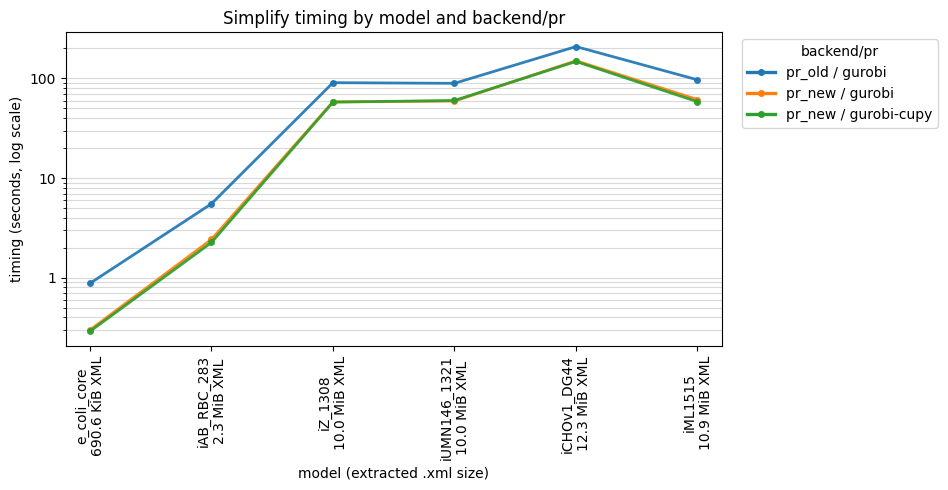

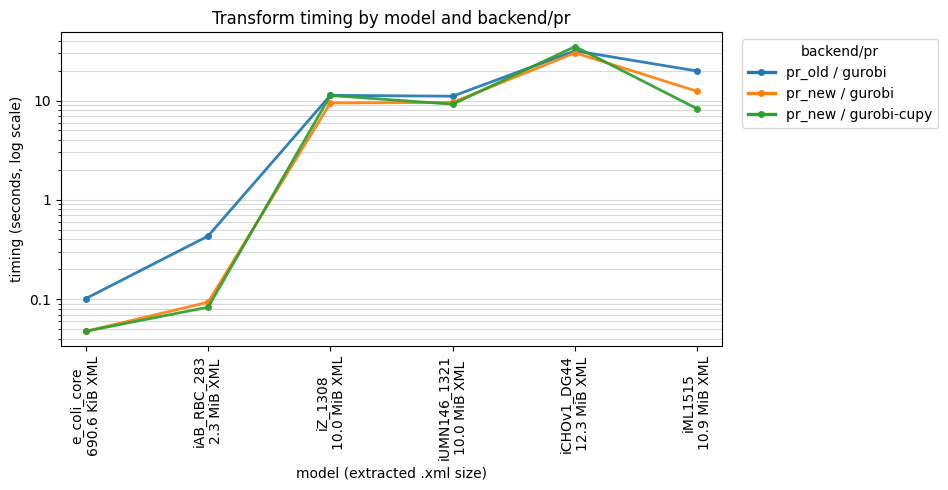

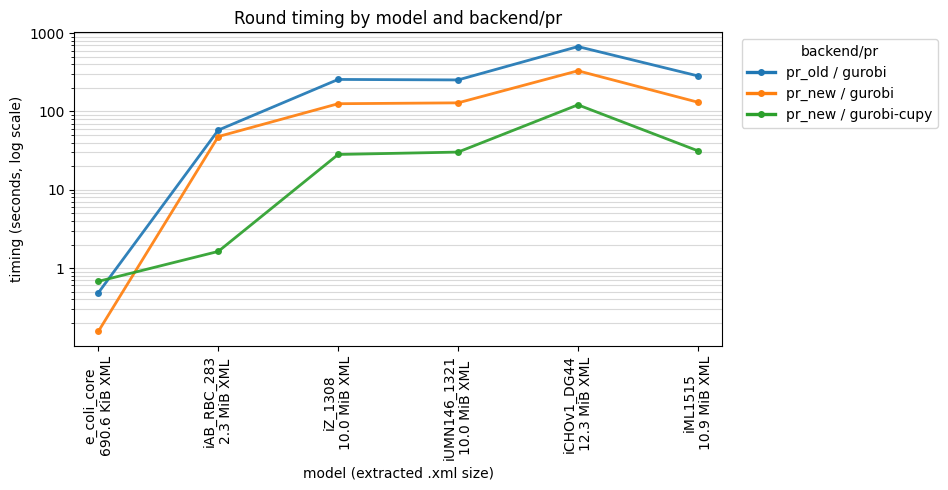

In [11]:
import gzip
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

if "timings" not in globals():
    raise RuntimeError("No timings found. Run the benchmark cell first.")

plot_rows = []
for row in timings:
    if row.get("stage") in {"parse", "total"}:
        continue
    plot_rows.append({**row, "run": f"{row['pr']} / {row['backend']}"})

if not plot_rows:
    raise RuntimeError("No non-parse stage timings found. Run the benchmark cell first.")


def unique_in_order(values):
    seen = set()
    result = []
    for value in values:
        if value not in seen:
            seen.add(value)
            result.append(value)
    return result


stage_order = ["simplify", "transform", "round"]
stages_present = set(row["stage"] for row in plot_rows)
stage_order = [stage for stage in stage_order if stage in stages_present]

models_dir = Path(globals().get("MODELS_DIR", Path("examples/test_data")))
selected_models = [Path(path) for path in globals().get("MODELS", [])]
timed_models = unique_in_order(row["model"] for row in plot_rows)
selected_model_names = [path.with_suffix("").name for path in selected_models]
model_order = [model for model in selected_model_names if model in timed_models]
model_order += [model for model in timed_models if model not in model_order]

configured_runs = []
for pr_name, _, backends in globals().get("RUNS", []):
    configured_runs.extend(f"{pr_name} / {backend}" for backend in backends)
timed_runs = unique_in_order(row["run"] for row in plot_rows)
run_order = [run for run in configured_runs if run in timed_runs]
run_order += [run for run in timed_runs if run not in run_order]


def extracted_xml_bytes(model_name):
    xml_path = models_dir / model_name
    if xml_path.exists():
        return xml_path.stat().st_size

    gz_path = next(
        (path for path in selected_models if path.with_suffix("").name == model_name),
        models_dir / f"{Path(model_name).stem}.xml.gz",
    )
    if not gz_path.exists():
        return np.nan

    size = 0
    with gzip.open(gz_path, "rb") as src:
        for chunk in iter(lambda: src.read(1024 * 1024), b""):
            size += len(chunk)
    return size


def format_bytes(size):
    if not np.isfinite(size):
        return "size unknown"
    size = float(size)
    for unit in ["B", "KiB", "MiB", "GiB"]:
        if size < 1024 or unit == "GiB":
            return f"{size:.0f} {unit}" if unit == "B" else f"{size:.1f} {unit}"
        size /= 1024


model_sizes = {model: extracted_xml_bytes(model) for model in model_order}
model_labels = {
    model: f"{Path(model).stem}\n{format_bytes(model_sizes[model])} XML"
    for model in model_order
}

seconds_by_key = {}
for row in plot_rows:
    key = (row["model"], row["run"], row["stage"])
    seconds_by_key[key] = seconds_by_key.get(key, 0.0) + float(row["seconds"])


run_cmap = plt.get_cmap("tab10")
run_colors = {run: run_cmap(i % run_cmap.N) for i, run in enumerate(run_order)}
run_handles = [
    Line2D([0], [0], color=run_colors[run], marker="o", linewidth=2.4, markersize=4, label=run)
    for run in run_order
]


def apply_timing_axis(ax, values):
    values = np.asarray(values, dtype=float).ravel()
    positive = values[np.isfinite(values) & (values > 0)]
    use_log = len(positive) > 1 and positive.max() / positive.min() >= 50
    if use_log:
        ax.set_yscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:g}"))
    ax.grid(True, axis="y", which="both", color="0.85", linewidth=0.8)
    return use_log


# One separate figure per non-parse stage.
x = np.arange(len(model_order))
for stage in stage_order:
    fig, ax = plt.subplots(figsize=(max(8, 1.6 * len(model_order)), 5.0))
    stage_values = []

    for run in run_order:
        seconds = np.array(
            [seconds_by_key.get((model, run, stage), np.nan) for model in model_order],
            dtype=float,
        )
        if np.isfinite(seconds).any():
            stage_values.extend(seconds[np.isfinite(seconds)])
            ax.plot(
                x,
                seconds,
                color=run_colors[run],
                marker="o",
                linewidth=2.0,
                markersize=4,
                alpha=0.92,
            )

    ax.set_title(f"{stage.capitalize()} timing by model and backend/pr")
    ax.set_ylabel("timing (seconds)")
    ax.set_xlabel("model (extracted .xml size)")
    ax.set_xticks(x)
    ax.set_xticklabels([model_labels[model] for model in model_order], rotation=90, ha="center", va="top")
    ax.margins(x=0.04)
    if apply_timing_axis(ax, stage_values):
        ax.set_ylabel("timing (seconds, log scale)")
    ax.legend(handles=run_handles, title="backend", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    plt.show()
